# Predicting Heart Disease with Machine Learning

<img src='https://www.news-medical.net/images/news/ImageForNews_776422_17123165547518811.jpg'>

Bu projede, Kaggle Playground Series S6E2 kapsamında verilen veri seti kullanılarak bir sınıflandırma problemi çözülmesi hedeflenmiştir. Amaç, farklı makine öğrenmesi algoritmalarını eğitip karşılaştırarak en yüksek performansı sağlayan modeli belirlemek ve veri üzerindeki örüntüleri doğru şekilde öğrenebilen bir sistem geliştirmektir.

In this project, a classification task was addressed using the dataset provided in the Kaggle Playground Series S6E2 competition. The main goal was to train and compare multiple machine learning algorithms to identify the model with the best performance and to develop a system capable of accurately capturing patterns in the data.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)

(630000, 15)
(270000, 14)


In [3]:
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [4]:
test.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [5]:
df=pd.concat([train,test]) 

### EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 900000 entries, 0 to 269999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       900000 non-null  int64  
 1   Age                      900000 non-null  int64  
 2   Sex                      900000 non-null  int64  
 3   Chest pain type          900000 non-null  int64  
 4   BP                       900000 non-null  int64  
 5   Cholesterol              900000 non-null  int64  
 6   FBS over 120             900000 non-null  int64  
 7   EKG results              900000 non-null  int64  
 8   Max HR                   900000 non-null  int64  
 9   Exercise angina          900000 non-null  int64  
 10  ST depression            900000 non-null  float64
 11  Slope of ST              900000 non-null  int64  
 12  Number of vessels fluro  900000 non-null  int64  
 13  Thallium                 900000 non-null  int64  
 14  Heart Dis

In [7]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,900000.0,449999.500000,259807.765474,0.0,224999.75,449999.5,674999.25,899999.0
Age,900000.0,54.143656,8.256054,29.0,48.00,54.0,60.00,77.0
Sex,900000.0,0.715209,0.451315,0.0,0.00,1.0,1.00,1.0
Chest pain type,900000.0,3.313459,0.851659,1.0,3.00,4.0,4.00,4.0
BP,900000.0,130.514730,14.985456,94.0,120.00,130.0,140.00,200.0
Cholesterol,900000.0,245.021851,33.685730,126.0,223.00,243.0,269.00,564.0
FBS over 120,900000.0,0.080007,0.271304,0.0,0.00,0.0,0.00,1.0
EKG results,900000.0,0.980710,0.998754,0.0,0.00,0.0,2.00,2.0
Max HR,900000.0,152.806861,19.125089,71.0,142.00,157.0,166.00,202.0
Exercise angina,900000.0,0.274004,0.446011,0.0,0.00,0.0,1.00,1.0


### Feature Engineering

In [9]:
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

In [10]:
abs(df.corr(numeric_only=True))['Heart Disease'].sort_values(ascending=False)

Heart Disease              1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Max HR                     0.440985
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
BP                         0.005181
id                         0.000209
Name: Heart Disease, dtype: float64

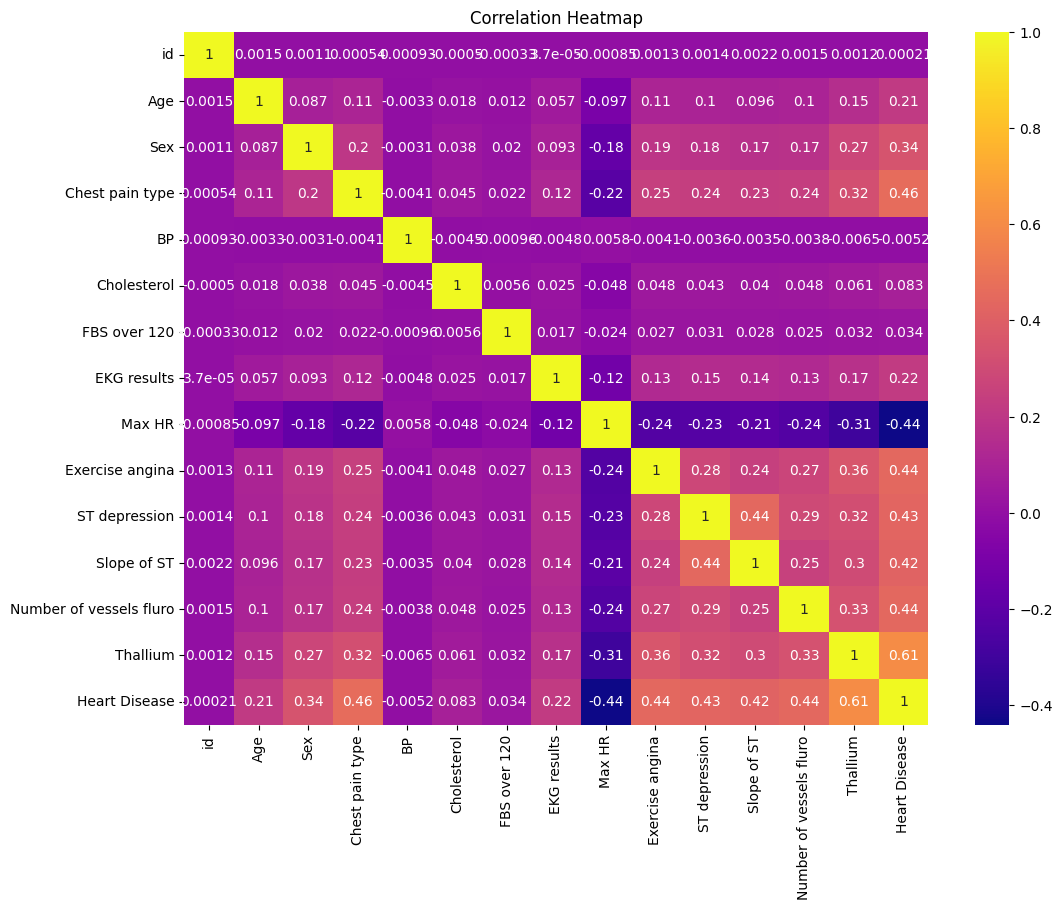

In [11]:
#Correlation Heatmap
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(), annot=True, cmap='plasma');
plt.title('Correlation Heatmap')
plt.show()

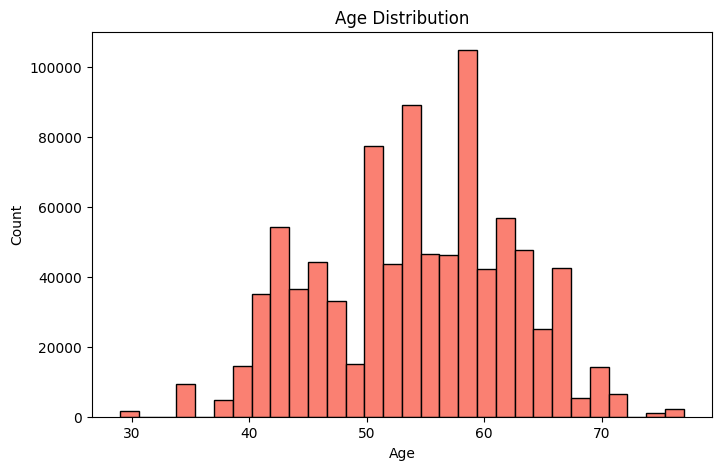

In [12]:
#Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=30, color='salmon', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

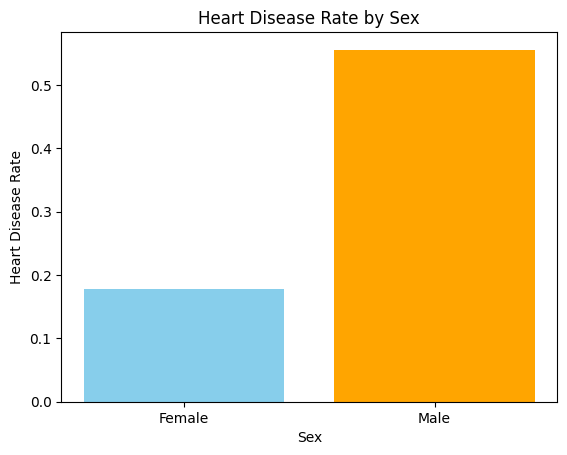

In [13]:
#Heart Disease Rate by Sex
sex_label = {0: 'Female', 1: 'Male'}
df_plot = df[~df['Heart Disease'].isna()]
heart_by_sex = df_plot.groupby('Sex')['Heart Disease'].mean()
plt.bar(['Female', 'Male'], heart_by_sex, color=['skyblue', 'orange'])
plt.title('Heart Disease Rate by Sex')
plt.ylabel('Heart Disease Rate')
plt.xlabel('Sex')
plt.show()

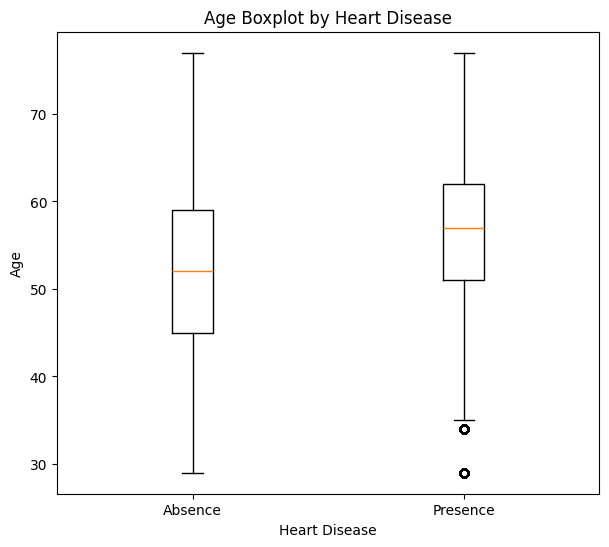

In [14]:
#Age Boxplot by Heart Disease
df_plot = df[~df['Heart Disease'].isna()]
plt.figure(figsize=(7, 6))
plt.boxplot([df_plot[df_plot['Heart Disease'] == 0]['Age'], 
             df_plot[df_plot['Heart Disease'] == 1]['Age']],
            labels=['Absence', 'Presence'])
plt.title('Age Boxplot by Heart Disease')
plt.xlabel('Heart Disease')
plt.ylabel('Age')
plt.show()

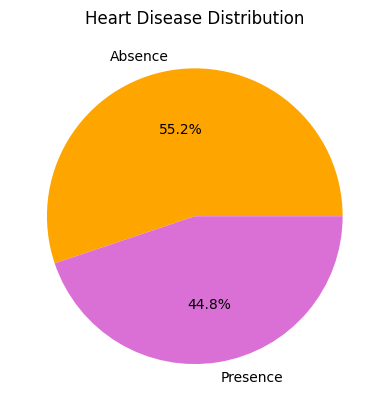

In [15]:
#Heart Disease Distribution
df_plot = df[~df['Heart Disease'].isna()]
labels = ['Absence', 'Presence']
sizes = [df_plot['Heart Disease'].value_counts()[0], df_plot['Heart Disease'].value_counts()[1]]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['Orange', 'Orchid'])
plt.title('Heart Disease Distribution')
plt.show()

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 900000 entries, 0 to 269999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       900000 non-null  int64  
 1   Age                      900000 non-null  int64  
 2   Sex                      900000 non-null  int64  
 3   Chest pain type          900000 non-null  int64  
 4   BP                       900000 non-null  int64  
 5   Cholesterol              900000 non-null  int64  
 6   FBS over 120             900000 non-null  int64  
 7   EKG results              900000 non-null  int64  
 8   Max HR                   900000 non-null  int64  
 9   Exercise angina          900000 non-null  int64  
 10  ST depression            900000 non-null  float64
 11  Slope of ST              900000 non-null  int64  
 12  Number of vessels fluro  900000 non-null  int64  
 13  Thallium                 900000 non-null  int64  
 14  Heart Dis

### Train- Test Split

In [17]:
train = df[~df['Heart Disease'].isna()]
test  = df[df['Heart Disease'].isna()]

In [18]:
del test ['Heart Disease']

In [19]:
x = train.drop(['id', 'Heart Disease'], axis=1)
y = train['Heart Disease']

### Model Training

In [20]:
def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB(),
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
        CatBoostClassifier(verbose=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "MultinomialNB",
        "XGBClassifier",
        "LGBMClassifier",
        "CatBoostClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        if isinstance(model, MultinomialNB):
            if (np.array(x_train) < 0).any():
                print("Uyarı: MultinomialNB negatif değerlerle çalışmaz, bu model atlanıyor!")
                accuracy.append(np.nan)
                precision.append(np.nan)
                recall.append(np.nan)
                f1.append(np.nan)
                mdl.append(None)
                continue
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="binary"))
            recall.append(recall_score(y_test, tahmin, average="binary"))
            f1.append(f1_score(y_test, tahmin, average="binary"))
            print(confusion_matrix(y_test, tahmin))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics.sort_values("F1", ascending=False, inplace=True)
    print("En başarılı model:", metrics.dropna().iloc[0].name)
    en_iyi_model = metrics.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("Classification Report:")
    print(classification_report(y_test, tahmin))

    print("\nDiğer Modeller:")
    print(metrics.drop("Model", axis=1))

    return metrics.drop("Model", axis=1)

In [21]:
algo_test(x,y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
[[58005 11559]
 [14940 41496]]
LogisticRegression modeli eğitiliyor...
[[62851  6713]
 [ 8164 48272]]
DecisionTreeClassifier modeli eğitiliyor...
[[58336 11228]
 [10830 45606]]
RandomForestClassifier modeli eğitiliyor...
[[62437  7127]
 [ 7910 48526]]
GradientBoostingClassifier modeli eğitiliyor...
[[62850  6714]
 [ 7640 48796]]
KNeighborsClassifier modeli eğitiliyor...
[[60487  9077]
 [12319 44117]]
AdaBoostClassifier modeli eğitiliyor...
[[62629  6935]
 [ 7589 48847]]
MultinomialNB modeli eğitiliyor...
[[61584  7980]
 [10555 45881]]
XGBClassifier modeli eğitiliyor...
[[62875  6689]
 [ 7550 48886]]
LGBMClassifier modeli eğitiliyor...
[[62839  6725]
 [ 7549 48887]]
CatBoostClassifier modeli eğitiliyor...
[[62870  6694]
 [ 7538 48898]]
Eğitim tamamlandı.
En başarılı model: CatBoostClassifier
Confusion Matrix:
[[62870  6694]
 [ 7538 48898]]
Classification Report:
              precision    recall  f1-score   support

 

,Accuracy,Precision,Recall,F1
CatBoostClassifier,0.887048,0.879587,0.866433,0.872960
XGBClassifier,0.886992,0.879640,0.866220,0.872879
LGBMClassifier,0.886714,0.879073,0.866238,0.872608
GradientBoostingClassifier,0.886079,0.879049,0.864625,0.871777
AdaBoostClassifier,0.884730,0.875677,0.865529,0.870573
LogisticRegression,0.881929,0.877912,0.855341,0.866479
RandomForestClassifier,0.880659,0.871939,0.859841,0.865848
MultinomialNB,0.852897,0.851841,0.812974,0.831954
DecisionTreeClassifier,0.824937,0.802442,0.808101,0.805262
KNeighborsClassifier,0.830190,0.829360,0.781717,0.804834


In [22]:
best_model=CatBoostClassifier()
best_model.fit(x,y)

Learning rate set to 0.16153
0:	learn: 0.5389424	total: 49.8ms	remaining: 49.8s
1:	learn: 0.4485665	total: 96ms	remaining: 47.9s
2:	learn: 0.3932286	total: 143ms	remaining: 47.4s
3:	learn: 0.3592697	total: 192ms	remaining: 47.8s
4:	learn: 0.3360708	total: 242ms	remaining: 48.2s
5:	learn: 0.3214720	total: 291ms	remaining: 48.1s
6:	learn: 0.3110291	total: 339ms	remaining: 48.1s
7:	learn: 0.3031616	total: 387ms	remaining: 48s
8:	learn: 0.2972465	total: 438ms	remaining: 48.2s
9:	learn: 0.2928822	total: 488ms	remaining: 48.3s
10:	learn: 0.2890993	total: 537ms	remaining: 48.3s
11:	learn: 0.2862560	total: 584ms	remaining: 48.1s
12:	learn: 0.2840390	total: 631ms	remaining: 47.9s
13:	learn: 0.2820498	total: 683ms	remaining: 48.1s
14:	learn: 0.2805497	total: 730ms	remaining: 47.9s
15:	learn: 0.2791667	total: 779ms	remaining: 47.9s
16:	learn: 0.2780533	total: 829ms	remaining: 47.9s
17:	learn: 0.2771634	total: 879ms	remaining: 47.9s
18:	learn: 0.2763506	total: 926ms	remaining: 47.8s
19:	learn: 0.2

CatBoostClassifier()

In [23]:
tahmin = best_model.predict_proba(test)[:,1]

In [24]:
sonuc = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': tahmin
})

In [25]:
sonuc

,id,Heart Disease
0,630000,0.965530
1,630001,0.007287
2,630002,0.990980
3,630003,0.003277
4,630004,0.186254
...,...,...
269995,899995,0.157687
269996,899996,0.670673
269997,899997,0.051424
269998,899998,0.171083


In [26]:
sonuc.to_csv("submission.csv", index=False)

Uygulanan modeller arasında en yüksek performansı CatBoostClassifier, XGBClassifier ve LGBMClassifier gibi gradient boosting tabanlı algoritmalar göstermiştir. Bu modeller yaklaşık %88 doğruluk oranına ulaşarak diğer yöntemlere göre daha başarılı sonuçlar üretmiştir. Genel olarak ensemble ve boosting yöntemlerinin, klasik algoritmalara kıyasla daha güçlü bir tahmin performansı sağladığı görülmüştür.

Among the applied models, gradient boosting–based algorithms such as CatBoostClassifier, XGBClassifier, and LGBMClassifier achieved the highest performance. These models reached an accuracy of around 88%, outperforming the other methods. Overall, ensemble and boosting techniques demonstrated stronger predictive power compared to more traditional algorithms.

